In [11]:
!ollama run qwen2.5


>>> Send a message (/? for help)/bye
... 


In [12]:
import ollama
llm = "qwen2.5"

In [13]:
stream = ollama.generate(model=llm, prompt='''what time is it?''', stream=True)
for chunk in stream:
    print(chunk['response'], end='', flush=True)

As an AI, I don't have real-time information about the current time. However, you can easily check the time on your device or through an online time zone calculator if needed! What would you like to know specifically about time or how can I assist you further with this?

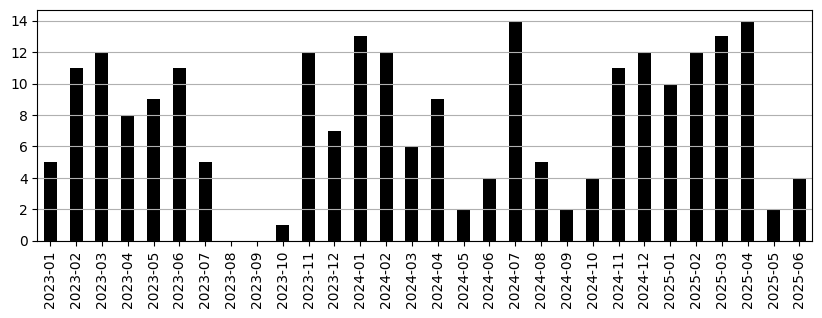

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## create data
np.random.seed(1) #<--for reproducibility
length = 30
ts = pd.DataFrame(data=np.random.randint(low=0, high=15, size=length),
                  columns=['y'],
                  index=pd.date_range(start='2023-01-01', freq='MS', periods=length).strftime('%Y-%m'))

## plot
ts.plot(kind="bar", figsize=(10,3), legend=False, color="black").grid(axis='y')

In [44]:
dtf = ts.reset_index().rename(columns={"index":"date"})
dtf.head()

,date,y
0,2023-01,5
1,2023-02,11
2,2023-03,12
3,2023-04,8
4,2023-05,9


In [7]:
data = dtf.to_dict(orient='records')
data[0:5]

[{'date': '2023-01', 'y': 5},
 {'date': '2023-02', 'y': 11},
 {'date': '2023-03', 'y': 12},
 {'date': '2023-04', 'y': 8},
 {'date': '2023-05', 'y': 9}]

In [8]:
str_data = "\n".join([str(row) for row in data])
str_data

"{'date': '2023-01', 'y': 5}\n{'date': '2023-02', 'y': 11}\n{'date': '2023-03', 'y': 12}\n{'date': '2023-04', 'y': 8}\n{'date': '2023-05', 'y': 9}\n{'date': '2023-06', 'y': 11}\n{'date': '2023-07', 'y': 5}\n{'date': '2023-08', 'y': 0}\n{'date': '2023-09', 'y': 0}\n{'date': '2023-10', 'y': 1}\n{'date': '2023-11', 'y': 12}\n{'date': '2023-12', 'y': 7}\n{'date': '2024-01', 'y': 13}\n{'date': '2024-02', 'y': 12}\n{'date': '2024-03', 'y': 6}\n{'date': '2024-04', 'y': 9}\n{'date': '2024-05', 'y': 2}\n{'date': '2024-06', 'y': 4}\n{'date': '2024-07', 'y': 14}\n{'date': '2024-08', 'y': 5}\n{'date': '2024-09', 'y': 2}\n{'date': '2024-10', 'y': 4}\n{'date': '2024-11', 'y': 11}\n{'date': '2024-12', 'y': 12}\n{'date': '2025-01', 'y': 10}\n{'date': '2025-02', 'y': 12}\n{'date': '2025-03', 'y': 13}\n{'date': '2025-04', 'y': 14}\n{'date': '2025-05', 'y': 2}\n{'date': '2025-06', 'y': 4}"

In [ ]:
prompt = f'''
Analyze this dataset, it contains monthly sales data of an online retail product:
{str_data}
'''

In [ ]:
messages = [{"role":"system", "content":prompt}]

while True:
    ## User
    q = input('🙂 >')
    if q == "quit":
        break
    messages.append( {"role":"user", "content":q} )

    ## Model
    agent_res = ollama.chat(model=llm, messages=messages, tools=[])
    res = agent_res["message"]["content"]

    ## Response
    print("👽 >", f"\x1b[1;30m{res}\x1b[0m")
    messages.append( {"role":"assistant", "content":res} )

🙂 >give me insight
👽 > Certainly! Let's analyze the given monthly sales data to extract meaningful insights:

### Data Overview:
The dataset contains monthly sales figures for an online retail product, spanning from January 2023 to June 2025. The variable `y` represents the sales quantity.

### Key Observations:
1. **Overall Sales Trend:**
   - There are several months where sales were zero or very low (e.g., August 2023, September 2023, February 2024).
   - Other months show higher sales, with peaks in March and December of both 2023 and 2024.
   - Sales seem to increase over time, reaching a high point in April 2024.

2. **Seasonal Patterns:**
   - There appears to be a seasonal pattern where some months have higher sales than others. For instance:
     - January through March 2023 had lower sales (5-12 units).
     - April and May 2023 saw an increase in sales (8-12 units).
     - June, July, and August 2023 had a dip with some months showing zero sales.
   - September through Decem

In [16]:
def final_answer(text:str) -> str:
    return text

tool_final_answer = {'type':'function', 'function':{
    'name': 'final_answer',
    'dsscription': 'Returns a natural language response to the user',
    'parameters': {'type': 'object',
                   'required': ['text'],
                   'properties': {'text': {'type':'str', 'description':'natural language response'}}
}}}

final_answer(text="hi")

'hi'

In [17]:
import io
import contextlib

def code_exec(code:str) -> str:
    output = io.StringIO()
    with contextlib.redirect_stdout(output):
        try:
            exec(code)
        except Exception as e:
            print(f"Error: {e}")
    return output.getvalue()

tool_code_exec = {'type':'function', 'function':{
  'name': 'code_exec',
  'description': 'Execute python code. Use always the function print() to get the output.',
  'parameters': {'type': 'object',
                 'required': ['code'],
                 'properties': {
                    'code': {'type':'str', 'description':'code to execute'},
}}}}

code_exec("from datetime import datetime; print(datetime.now().strftime('%H:%M'))")

'06:05\n'

In [18]:
dic_tools = {"final_answer":final_answer, "code_exec":code_exec}

In [19]:
# Prompt
str_data = "\n".join([str(row) for row in dtf.to_dict(orient='records')])

prompt = f'''
You are a Data Analyst, you will be given a task to solve as best you can.
You have access to the following tools:
- tool 'code_exec' to execute Python code.
- tool 'final_answer' to return a text response.

If you use the 'code_exec' tool, remember to always use the function print() to get the output.

This dataset contains monthly sales of an oline retail product:
{str_data}
'''

In [25]:
def use_tool(agent_res:dict, dic_tools:dict) -> dict:
    ## use tool
    if "tool_calls" in agent_res["message"]:
        for tool in agent_res["message"]["tool_calls"]:
            t_name, t_inputs = tool["function"]["name"], tool["function"]["arguments"]
            if f := dic_tools.get(t_name):
                ### calling tool
                print('🔧 >', f"\x1b[1;31m{t_name} -> Inputs: {t_inputs}\x1b[0m")
                ### tool output
                t_output = f(**tool["function"]["arguments"])
                print(t_output)
                ### final res
                res = t_output
            else:
                print('🤬 >', f"\x1b[1;31m{t_name} -> NotFound\x1b[0m")
    ## don't use tool
    if agent_res['message']['content'] != '':
        res = agent_res["message"]["content"]
        t_name, t_inputs = '', ''
    return {'res':res, 'tool_used':t_name, 'inputs_used':t_inputs}

In [31]:
def run_agent(llm, messages, available_tools):
    tool_used, local_memory = '', ''

    while tool_used != 'final_answer':
        ### use tools
        try:
            agent_res = ollama.chat(model=llm,
                                    messages=messages,
                                    tools=[v for v in available_tools.values()])
            dic_res = use_tool(agent_res, dic_tools)
            res, tool_used, inputs_used = dic_res["res"], dic_res["tool_used"], dic_res["inputs_used"]
        ### error
        except Exception as e:
            print("⚠️ >", e)
            res = f"I tried to use {tool_used} but didn't work. I will try something else."
            print("👽 >", f"\x1b[1;30m{res}\x1b[0m")
            messages.append({"role":"assistant", "content":res})

        ### update memory
        if tool_used not in ['','final_answer']:
            local_memory += f"\nTool used: {tool_used}.\nInput used: {inputs_used}.\nOutput: {res}"
            messages.append( {"role":"assistant", "content":local_memory})
            available_tools.pop(tool_used)
            if len(available_tools) == 1:
                messages.append( {"role":"user", "content":"Now activate tool final_answer."})

        ### tools not used
        if tool_used == '':
            break
    return res

🙂 >
🔧 > final_answer -> Inputs: {'text': "The dataset you provided is stored in the variable 'dtf'. Let's take a look at the first few rows to confirm its structure."}
The dataset you provided is stored in the variable 'dtf'. Let's take a look at the first few rows to confirm its structure.
👽 > The dataset you provided is stored in the variable 'dtf'. Let's take a look at the first few rows to confirm its structure.
🙂 >analyzing trends
🔧 > code_exec -> Inputs: {'code': 'print(dtf.head())'}
      date   y
0  2023-01   5
1  2023-02  11
2  2023-03  12
3  2023-04   8
4  2023-05   9

🔧 > final_answer -> Inputs: {'text': 'To analyze trends in the sales data, we can start by calculating some basic statistics and visualizing the data.'}
To analyze trends in the sales data, we can start by calculating some basic statistics and visualizing the data.
👽 > To analyze trends in the sales data, we can start by calculating some basic statistics and visualizing the data.
🙂 >ok, plot it


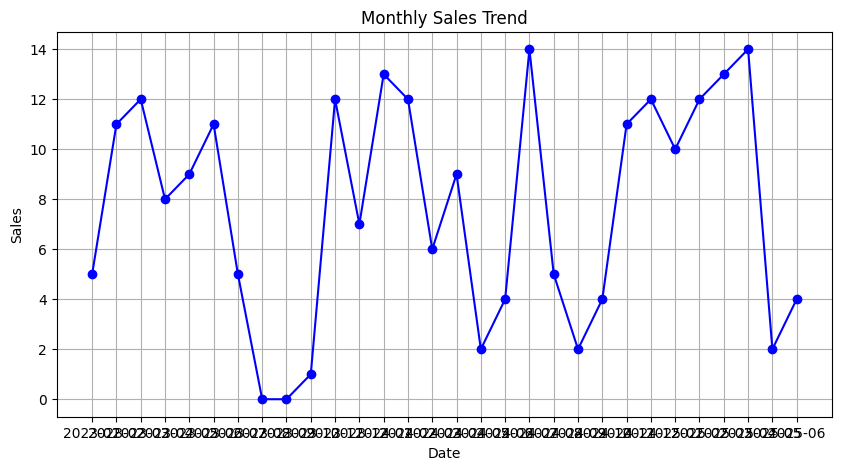

🔧 > code_exec -> Inputs: {'code': "import matplotlib.pyplot as plt\n\n# Extract date and sales columns\ndate = dtf['date']\nsales = dtf['y']\n\n# Plotting the sales data\nplt.figure(figsize=(10, 5))\nplt.plot(date, sales, marker='o', linestyle='-', color='b')\nplt.title('Monthly Sales Trend')\nplt.xlabel('Date')\nplt.ylabel('Sales')\nplt.grid(True)\nplt.show()"}

🔧 > final_answer -> Inputs: {'text': "The plot shows the monthly sales trend over time. There are some fluctuations in sales, with peaks in certain months and troughs in others. Overall, there doesn't appear to be a clear upward or downward trend in sales."}
The plot shows the monthly sales trend over time. There are some fluctuations in sales, with peaks in certain months and troughs in others. Overall, there doesn't appear to be a clear upward or downward trend in sales.
👽 > The plot shows the monthly sales trend over time. There are some fluctuations in sales, with peaks in certain months and troughs in others. Overall, the

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
<string>:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.


🔧 > final_answer -> Inputs: {'text': 'The forecast for the next 6 months using exponential smoothing shows that all predicted sales values are NaN, indicating that the model was unable to generate meaningful predictions based on the provided data.'}
The forecast for the next 6 months using exponential smoothing shows that all predicted sales values are NaN, indicating that the model was unable to generate meaningful predictions based on the provided data.
👽 > The forecast for the next 6 months using exponential smoothing shows that all predicted sales values are NaN, indicating that the model was unable to generate meaningful predictions based on the provided data.
🙂 >retry forecast the next 6 months


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
<string>:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.


🔧 > code_exec -> Inputs: {'code': "from statsmodels.tsa.holtwinters import SimpleExpSmoothing\nimport pandas as pd\n\n# Convert the date column to datetime format\ndtf['date'] = pd.to_datetime(dtf['date'])\n\n# Set the date column as the index\nindex = dtf.set_index('date')['y']\n\n# Fit the simple exponential smoothing model\nmodel = SimpleExpSmoothing(index)\nfitted_model = model.fit()\n\n# Forecast the next 6 months\nforecast = fitted_model.forecast(6)\n\n# Convert the forecast to a DataFrame with proper date range\nforecast_df = pd.DataFrame(forecast, index=pd.date_range(start=dtf['date'].max(), periods=7, freq='M')[1:], columns=['y'])\n\n# Display the forecasted values\nprint(forecast_df)"}
             y
2025-07-31 NaN
2025-08-31 NaN
2025-09-30 NaN
2025-10-31 NaN
2025-11-30 NaN
2025-12-31 NaN

👽 > Let's try using a different approach for forecasting the next 6 months. We can use the Simple Exponential Smoothing (SES) method which is simpler and might work better with this type of

In [46]:
# Start a Chat
messages = [{"role":"system", "content":prompt}]
memory = '''
The dataset already exists and it's called 'dtf, don't create a new one.
'''

while True:
    ## User
    q = input('🙂 >')
    if q == "quit":
        break
    messages.append( {"role":"user", "content":q} )

    ## Memory
    messages.append( {"role":"user", "content":memory} )

    ## Model
    available_tools = {"final_answer":tool_final_answer, "code_exec":tool_code_exec}
    res = run_agent(llm, messages, available_tools)

    ## Response
    print("👽 >", f"\x1b[1;30m{res}\x1b[0m")
    messages.append( {"role":"assistant", "content":res} )

In [47]:
messages

[{'role': 'system',
  'content': "\nYou are a Data Analyst, you will be given a task to solve as best you can.\nYou have access to the following tools:\n- tool 'code_exec' to execute Python code.\n- tool 'final_answer' to return a text response.\n\nIf you use the 'code_exec' tool, remember to always use the function print() to get the output.\n\nThis dataset contains monthly sales of an oline retail product:\n{'date': '2023-01', 'y': 5}\n{'date': '2023-02', 'y': 11}\n{'date': '2023-03', 'y': 12}\n{'date': '2023-04', 'y': 8}\n{'date': '2023-05', 'y': 9}\n{'date': '2023-06', 'y': 11}\n{'date': '2023-07', 'y': 5}\n{'date': '2023-08', 'y': 0}\n{'date': '2023-09', 'y': 0}\n{'date': '2023-10', 'y': 1}\n{'date': '2023-11', 'y': 12}\n{'date': '2023-12', 'y': 7}\n{'date': '2024-01', 'y': 13}\n{'date': '2024-02', 'y': 12}\n{'date': '2024-03', 'y': 6}\n{'date': '2024-04', 'y': 9}\n{'date': '2024-05', 'y': 2}\n{'date': '2024-06', 'y': 4}\n{'date': '2024-07', 'y': 14}\n{'date': '2024-08', 'y': 5}\n